
TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN
---Gradient Check---
 Relative Error: 0.00000007
Gradient is ✅

TEST 2: NUMPY vs PYTORCH
--- local PyTorch vs NumPy Check---
Max difference between NumPy and PyTorch outputs: 0.00000000
✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.

Statring Numpy Training
Epoch 01/15 | Train Loss: 1.7355
Epoch 02/15 | Train Loss: 1.6478
Epoch 03/15 | Train Loss: 1.5902
Epoch 04/15 | Train Loss: 1.5525
Epoch 05/15 | Train Loss: 1.5277
Epoch 06/15 | Train Loss: 1.5109
Epoch 07/15 | Train Loss: 1.4992
Epoch 08/15 | Train Loss: 1.4906
Epoch 09/15 | Train Loss: 1.4838
Epoch 10/15 | Train Loss: 1.4781
Epoch 11/15 | Train Loss: 1.4728
Epoch 12/15 | Train Loss: 1.4675
Epoch 13/15 | Train Loss: 1.4619
Epoch 14/15 | Train Loss: 1.4559
Epoch 15/15 | Train Loss: 1.4494
Numpy Total Training Time: 49.56 seconds

--- Evaluation Results for NumPy RNN ---
Accuracy: 46.69%
Macro-F1 Score: 0.1732

Per-Class F1 Scores:
  Walking: 0.6002
  Jogging: 0.4390
 

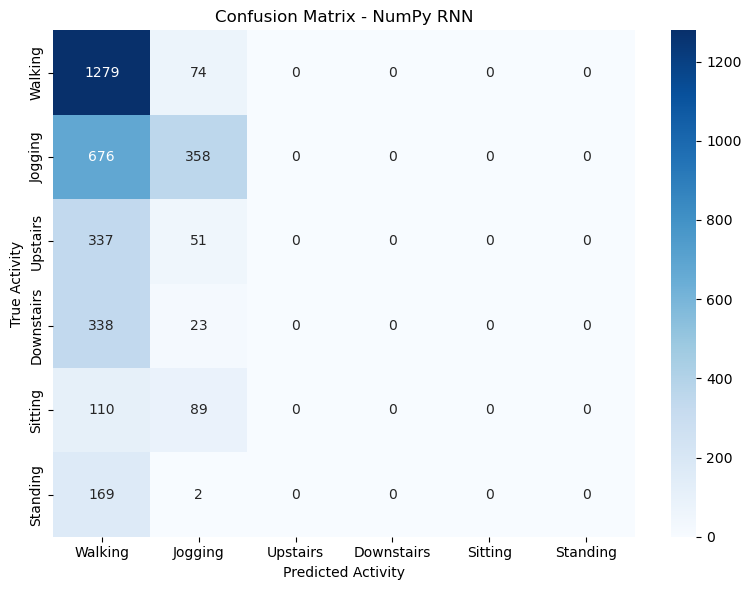


Statring PyTorch Training  PyTorch LSTM
Epoch 01/15 | Train Loss: 1.2465
Epoch 02/15 | Train Loss: 0.8609
Epoch 03/15 | Train Loss: 0.7222
Epoch 04/15 | Train Loss: 0.6827
Epoch 05/15 | Train Loss: 0.6034
Epoch 06/15 | Train Loss: 0.5062
Epoch 07/15 | Train Loss: 0.4599
Epoch 08/15 | Train Loss: 0.4095
Epoch 09/15 | Train Loss: 0.3660
Epoch 10/15 | Train Loss: 0.3093
Epoch 11/15 | Train Loss: 0.3030
Epoch 12/15 | Train Loss: 0.2592
Epoch 13/15 | Train Loss: 0.2491
Epoch 14/15 | Train Loss: 0.2157
Epoch 15/15 | Train Loss: 0.1948
PyTorch Total Training Time PyTorch LSTM: 24.53 seconds

--- Evaluation Results for PyTorch LSTM ---
Accuracy: 77.90%
Macro-F1 Score: 0.7485

Per-Class F1 Scores:
  Walking: 0.8137
  Jogging: 0.8925
  Upstairs: 0.4860
  Downstairs: 0.6067
  Sitting: 0.8367
  Standing: 0.8555


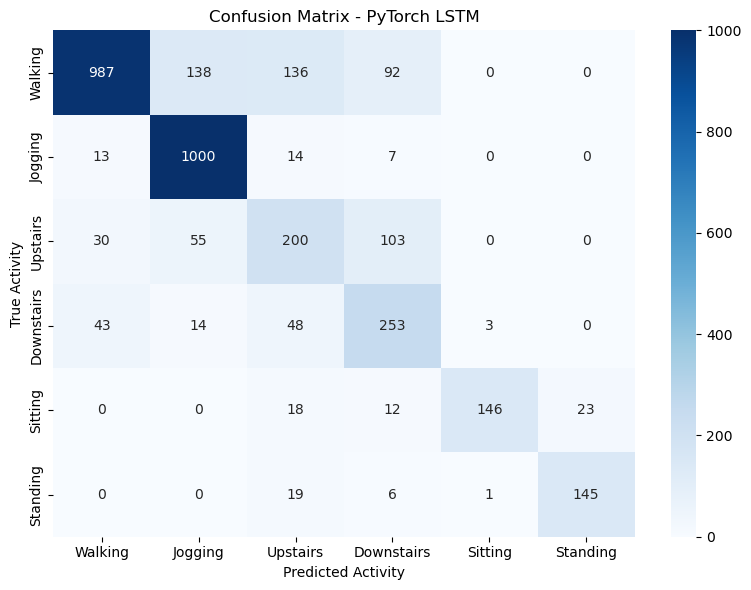


Statring PyTorch Training  PyTorch BiLSTM
Epoch 01/15 | Train Loss: 1.2088
Epoch 02/15 | Train Loss: 0.8241
Epoch 03/15 | Train Loss: 0.7201
Epoch 04/15 | Train Loss: 0.6482
Epoch 05/15 | Train Loss: 0.5585
Epoch 06/15 | Train Loss: 0.5107
Epoch 07/15 | Train Loss: 0.4545
Epoch 08/15 | Train Loss: 0.4040
Epoch 09/15 | Train Loss: 0.3881
Epoch 10/15 | Train Loss: 0.3510
Epoch 11/15 | Train Loss: 0.2980
Epoch 12/15 | Train Loss: 0.2440
Epoch 13/15 | Train Loss: 0.2269
Epoch 14/15 | Train Loss: 0.2044
Epoch 15/15 | Train Loss: 0.2179
PyTorch Total Training Time PyTorch BiLSTM: 45.49 seconds

--- Evaluation Results for PyTorch BiLSTM ---
Accuracy: 77.01%
Macro-F1 Score: 0.6993

Per-Class F1 Scores:
  Walking: 0.8246
  Jogging: 0.8876
  Upstairs: 0.4282
  Downstairs: 0.5372
  Sitting: 0.8373
  Standing: 0.6806


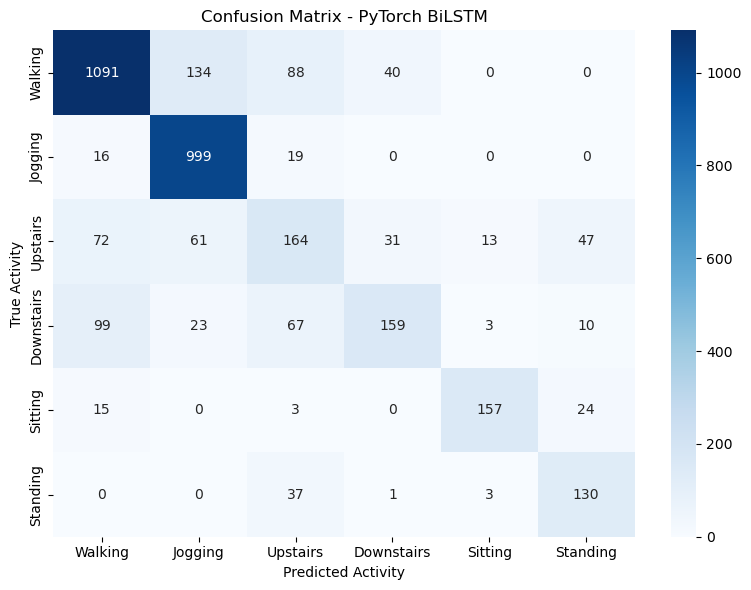


1. NumPy Simple RNN : Time = 49.56s | Accuracy = 46.69% | Macro-F1 = 0.1732
2. PyTorch LSTM     : Time = 24.53s | Accuracy = 77.90% | Macro-F1 = 0.7485
3. PyTorch BiLSTM   : Time = 45.49s | Accuracy = 77.01% | Macro-F1 = 0.6993


In [2]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from scipy import stats

np.random.seed(42)
try:
    FILE_PATH = Path(__file__).resolve().parent
except NameError:
    FILE_PATH = Path.cwd()

ACTIVITY_MAP = {
    "Walking": 0,
    "Jogging": 1,
    "Upstairs": 2,
    "Downstairs": 3,
    "Sitting": 4,
    "Standing": 5,
}
INT_TO_ACTIVITY = {v: k for k, v in ACTIVITY_MAP.items()}


def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)


class NumPyRNN:

    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.lr = learning_rate
        self.hidden_dim = hidden_dim

        scale = 0.01
        self.Wxh = np.random.randn(input_dim, hidden_dim) * scale
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * scale
        self.Wyh = np.random.randn(hidden_dim, output_dim) * scale

        self.bh = np.zeros((1, hidden_dim))
        self.by = np.zeros((1, output_dim))

    def forward(self, X):
        batch_size, window_length, _ = X.shape

        hs = np.zeros((batch_size, window_length + 1, self.hidden_dim))

        for t in range(window_length):
            net_input = X[:, t, :] @ self.Wxh + hs[:, t - 1, :] @ self.Whh + self.bh
            hs[:, t, :] = np.tanh(net_input)

        last_hidden = hs[:, window_length - 1, :]
        logits = last_hidden @ self.Wyh + self.by
        probs = softmax(logits)

        cache = (X, hs, probs)
        return probs, cache

    @staticmethod
    def cross_entropy_loss(probs, y_true):
        epsilon = 1e-12
        n = probs.shape[0]
        correct_probs = probs[np.arange(n), y_true]
        loss = -np.mean(np.log(correct_probs + epsilon))
        return loss

    def backward(self, y_true, cache):
        X, hs, probs = cache
        batch_size, window_length, _ = X.shape

        dlogits = probs.copy()
        dlogits[np.arange(batch_size), y_true] -= 1
        dlogits /= batch_size

        last_hidden = hs[:, window_length - 1, :]
        dWyh = last_hidden.T @ dlogits
        dby = np.sum(dlogits, axis=0, keepdims=True)

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)

        dh_next = dlogits @ self.Wyh.T

        for t in reversed(range(window_length)):
            dtanh = (1 - hs[:, t, :] ** 2) * dh_next

            dWxh += X[:, t, :].T @ dtanh
            dWhh += hs[:, t - 1, :].T @ dtanh
            dbh += np.sum(dtanh, axis=0, keepdims=True)

            dh_next = dtanh @ self.Whh.T

        return {"dWxh": dWxh, "dWhh": dWhh, "dWyh": dWyh, "dbh": dbh, "dby": dby}

    def update_params(self, grads, max_grad_norm=5.0):
        for key in grads:
            grads[key] = np.clip(grads[key], -max_grad_norm, max_grad_norm)

        self.Wxh -= self.lr * grads["dWxh"]
        self.Whh -= self.lr * grads["dWhh"]
        self.Wyh -= self.lr * grads["dWyh"]
        self.bh -= self.lr * grads["dbh"]
        self.by -= self.lr * grads["dby"]


def create_windows(data, window_size=200, step_size=100):

    X_list = []
    Y_list = []

    for _, group in data.groupby("user"):
        features = group[["x", "y", "z"]].values
        activities = group["activity"].values

        for i in range(0, len(group) - window_size + 1, step_size):

            X_list.append(features[i : i + window_size])

            window_labels = activities[i : i + window_size]
            dominant_label = stats.mode(window_labels, keepdims=False)[0]
            Y_list.append(dominant_label)

    return np.array(X_list), np.array(Y_list)


def load_dataset():

    dataset_path = FILE_PATH / "dataset" / "WISDM_ar_v1.1_cleaned.csv"
    dataset = pd.read_csv(
        dataset_path,
        dtype={"user": int, "timestamp": float, "x": float, "y": float, "z": float},
    )
    # print("Dataset Type: " + str(type(dataset)))

    dataset["activity"] = dataset["activity"].map(ACTIVITY_MAP)

    # print("Dataset Head: " + str(dataset.head()))

    train_dataset = dataset[(dataset["user"]) <= 25].copy()
    test_dataset = dataset[dataset["user"] > 25].copy()

    train_features = train_dataset[["x", "y", "z"]].values
    test_features = test_dataset[["x", "y", "z"]].values

    # print("Train Features:\n" + str(train_features[0:10]))

    mean = np.mean(train_features, axis=0)
    std = np.std(train_features, axis=0) + 1e-8  # 1e-8 prevents division by zero

    train_dataset[["x", "y", "z"]] = (train_features - mean) / std

    test_dataset[["x", "y", "z"]] = (test_features - mean) / std

    return dataset, train_dataset, test_dataset


def check_gradient_numerical(model, X_sample, y_sample, epsilon=1e-7):
    print("---Gradient Check---")

    probs, cache = model.forward(X_sample)
    analytic_grads = model.backward(y_sample, cache)
    dWxh_analytic = analytic_grads["dWxh"]

    dWxh_num = np.zeros_like(model.Wxh)

    for i in range(model.Wxh.shape[0]):
        for j in range(model.Wxh.shape[1]):
            orig_val = model.Wxh[i, j]

            model.Wxh[i, j] = orig_val + epsilon
            probs_plus, _ = model.forward(X_sample)
            loss_plus = model.cross_entropy_loss(probs_plus, y_sample)

            model.Wxh[i, j] = orig_val - epsilon
            probs_minus, _ = model.forward(X_sample)
            loss_minus = model.cross_entropy_loss(probs_minus, y_sample)

            dWxh_num[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

            model.Wxh[i, j] = orig_val

    numerator = np.linalg.norm(dWxh_analytic - dWxh_num)
    denominator = np.linalg.norm(dWxh_analytic) + np.linalg.norm(dWxh_num) + 1e-12
    relative_error = numerator / denominator

    print(f" Relative Error: {relative_error:.8f}")
    if relative_error < 1e-5:
        print("Gradient is ✅")
    else:
        print("Gradient is ❌")


def local_Numpy_vs_nnRnn_check(
    numpy_model, input_dim, hidden_dim, batch_size=2, window_len=10
):
    print("--- local PyTorch vs NumPy Check---")

    pytorch_rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

    with torch.no_grad():
        pytorch_rnn.weight_ih_l0.copy_(torch.from_numpy(numpy_model.Wxh.T).float())
        pytorch_rnn.weight_hh_l0.copy_(torch.from_numpy(numpy_model.Whh.T).float())
        pytorch_rnn.bias_ih_l0.copy_(torch.from_numpy(numpy_model.bh.squeeze()).float())
        pytorch_rnn.bias_hh_l0.zero_()

    X_test_np = np.random.randn(batch_size, window_len, input_dim)
    X_test_torch = torch.from_numpy(X_test_np).float()

    _, cache = numpy_model.forward(X_test_np)
    out_numpy = cache[1][:, window_len - 1, :]

    out_torch, _ = pytorch_rnn(X_test_torch)
    out_torch_last = out_torch[:, -1, :].detach().numpy()

    diff = np.max(np.abs(out_numpy - out_torch_last))
    print(f"Max difference between NumPy and PyTorch outputs: {diff:.8f}")
    if diff < 1e-5:
        print("✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.")
    else:
        print("❌ Warning! Significant difference detected between outputs.")


class PyTorchSimpleRNN_Simple(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


class PyTorchLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


class PyTorchBiLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


def evaluate_and_report(y_true, y_pred, model_name="Model"):

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(y_true, y_pred, average="macro")

    class_f1 = f1_score(y_true, y_pred, average=None)

    print(f"\n--- Evaluation Results for {model_name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1:.4f}")

    activity_names = [
        "Walking",
        "Jogging",
        "Upstairs",
        "Downstairs",
        "Sitting",
        "Standing",
    ]
    print("\nPer-Class F1 Scores:")
    for name, f1 in zip(activity_names, class_f1):
        print(f"  {name}: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=activity_names,
        yticklabels=activity_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Activity")
    plt.xlabel("Predicted Activity")
    plt.tight_layout()
    plt.show()

    return acc, macro_f1, cm


def train_numpy_rnn(
    model, X_train, y_train, X_test, y_test, epochs=15, batch_size=64, max_grad_norm=5.0
):
    print("\n" + "=" * 60)
    print("Statring Numpy Training")
    print("=" * 60)

    start_time = time.time()
    num_samples = X_train.shape[0]

    for epoch in range(epochs):
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        epoch_loss = 0.0
        num_batches = int(np.ceil(num_samples / batch_size))

        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_samples)

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            probs, cache = model.forward(X_batch)
            loss = model.cross_entropy_loss(probs, y_batch)
            epoch_loss += loss * (end_idx - start_idx)

            grads = model.backward(y_batch, cache)
            model.update_params(grads, max_grad_norm)

        epoch_loss /= num_samples
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"Numpy Total Training Time: {train_time:.2f} seconds")

    test_samples = X_test.shape[0]
    test_batches = int(np.ceil(test_samples / batch_size))
    y_pred_list = []

    for b in range(test_batches):
        start_idx = b * batch_size
        end_idx = min(start_idx + batch_size, test_samples)
        X_batch = X_test[start_idx:end_idx]
        probs, _ = model.forward(X_batch)
        y_pred_list.append(np.argmax(probs, axis=1))

    y_pred = np.concatenate(y_pred_list, axis=0)
    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, "NumPy RNN")
    return train_time, acc, macro_f1


def train_pytorch_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=15,
    batch_size=64,
    lr=0.005,
    model_name="PyTorch Model",
):
    print("\n" + "=" * 60)
    print(f"Statring PyTorch Training  {model_name}")
    print("=" * 60)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    X_test_tensor = torch.from_numpy(X_test).float()

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)

        epoch_loss /= len(train_dataset)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"PyTorch Total Training Time {model_name}: {train_time:.2f} seconds")

    model.eval()
    with torch.no_grad():
        test_outputs = []
        num_test = X_test_tensor.size(0)
        test_batches = int(np.ceil(num_test / batch_size))
        for b in range(test_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_test)
            out = model(X_test_tensor[start_idx:end_idx])
            test_outputs.append(torch.argmax(out, dim=1).numpy())

        y_pred = np.concatenate(test_outputs, axis=0)

    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, model_name)
    return train_time, acc, macro_f1


def main():
    dataset, train_dataset, test_dataset = load_dataset()

    X_train, y_train = create_windows(train_dataset)
    X_test, y_test = create_windows(test_dataset)
    # print("X_train shape:", X_train.shape)
    # print("y_train shape:", y_train.shape)

    input_dim = X_train.shape[2]
    hidden_dim = 32
    output_dim = 6
    learning_rate = 0.01

    numpy_model = NumPyRNN(
        input_dim, hidden_dim, output_dim, learning_rate=learning_rate
    )

    # TEST 1: Numerical Gradient Check (Section 2 Requirement)
    print("\n" + "=" * 60)
    print("TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN")
    print("=" * 60)
    check_gradient_numerical(numpy_model, X_train[:2], y_train[:2])

    # TEST 2: Sanity Check with PyTorch nn.RNN (Section 3 Requirement)
    print("\n" + "=" * 60)
    print("TEST 2: NUMPY vs PYTORCH")
    print("=" * 60)
    local_Numpy_vs_nnRnn_check(
        numpy_model, input_dim, hidden_dim, batch_size=2, window_len=X_train.shape[1]
    )

    # Pytorch training and testing
    numpy_model = NumPyRNN(input_dim, hidden_dim, output_dim, learning_rate=0.01)
    time_np, acc_np, f1_np = train_numpy_rnn(
        numpy_model, X_train, y_train, X_test, y_test, epochs=15
    )

    # LSTM training and testing
    lstm_model = PyTorchLSTM(input_dim, hidden_dim, output_dim)
    time_lstm, acc_lstm, f1_lstm = train_pytorch_model(
        lstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch LSTM",
    )

    # BiLSTM training and testing
    bilstm_model = PyTorchBiLSTM(input_dim, hidden_dim, output_dim)
    time_bilstm, acc_bilstm, f1_bilstm = train_pytorch_model(
        bilstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch BiLSTM",
    )

    print("\n" + "=" * 70)
    print("=" * 70)
    print(
        f"1. NumPy Simple RNN : Time = {time_np:.2f}s | Accuracy = {acc_np*100:.2f}% | Macro-F1 = {f1_np:.4f}"
    )
    print(
        f"2. PyTorch LSTM     : Time = {time_lstm:.2f}s | Accuracy = {acc_lstm*100:.2f}% | Macro-F1 = {f1_lstm:.4f}"
    )
    print(
        f"3. PyTorch BiLSTM   : Time = {time_bilstm:.2f}s | Accuracy = {acc_bilstm*100:.2f}% | Macro-F1 = {f1_bilstm:.4f}"
    )
    print("=" * 70)


if __name__ == "__main__":
    main()

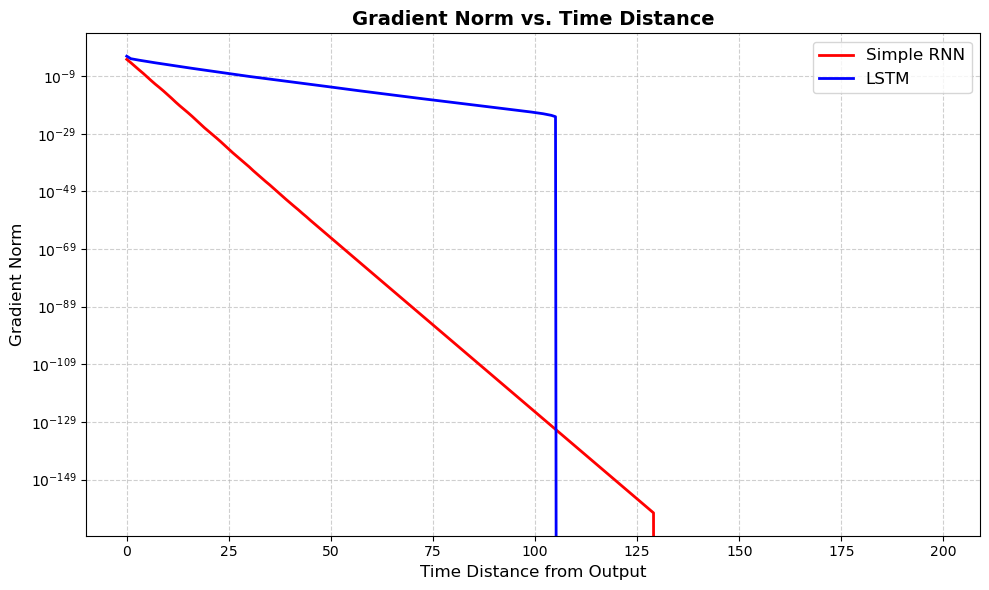

In [5]:
def plot_gradient_norms(numpy_rnn_model, pytorch_lstm_model, X_sample, y_sample):
    window_length = X_sample.shape[1]

    probs, cache = numpy_rnn_model.forward(X_sample)
    X, hs, _ = cache
    batch_size = X_sample.shape[0]

    dlogits = probs.copy()
    dlogits[np.arange(batch_size), y_sample] -= 1
    dlogits /= batch_size

    dh_next = dlogits @ numpy_rnn_model.Wyh.T
    rnn_grad_norms = []

    for t in reversed(range(window_length)):
        norm_val = np.mean(np.linalg.norm(dh_next, axis=-1))
        rnn_grad_norms.append(norm_val)

        dtanh = (1 - hs[:, t, :] ** 2) * dh_next
        dh_next = dtanh @ numpy_rnn_model.Whh.T

    time_distances = np.arange(window_length)

    pytorch_lstm_model.eval()
    pytorch_lstm_model.zero_grad()

    X_tensor = torch.from_numpy(X_sample).float()
    y_tensor = torch.from_numpy(y_sample).long()

    batch_size, _, input_dim = X_tensor.shape
    hidden_dim = pytorch_lstm_model.lstm.hidden_size

    lstm_cell = nn.LSTMCell(input_dim, hidden_dim)
    lstm_cell.weight_ih.data = pytorch_lstm_model.lstm.weight_ih_l0.data
    lstm_cell.weight_hh.data = pytorch_lstm_model.lstm.weight_hh_l0.data
    lstm_cell.bias_ih.data = pytorch_lstm_model.lstm.bias_ih_l0.data
    lstm_cell.bias_hh.data = pytorch_lstm_model.lstm.bias_hh_l0.data

    hx = torch.zeros(batch_size, hidden_dim)
    cx = torch.zeros(batch_size, hidden_dim)

    hidden_states = []
    for t in range(window_length):
        hx, cx = lstm_cell(X_tensor[:, t, :], (hx, cx))
        hx.retain_grad()
        hidden_states.append(hx)

    logits = pytorch_lstm_model.fc(hidden_states[-1])
    loss = nn.CrossEntropyLoss()(logits, y_tensor)
    loss.backward()

    lstm_grad_norms_step = [
        np.mean(np.linalg.norm(h.grad.detach().numpy(), axis=-1)) for h in hidden_states
    ]
    lstm_grad_norms = lstm_grad_norms_step[::-1]

    plt.figure(figsize=(10, 6))
    plt.plot(
        time_distances, rnn_grad_norms, label="Simple RNN", color="red", linewidth=2
    )
    plt.plot(time_distances, lstm_grad_norms, label="LSTM", color="blue", linewidth=2)

    plt.title("Gradient Norm vs. Time Distance", fontsize=14, fontweight="bold")
    plt.xlabel("Time Distance from Output", fontsize=12)
    plt.ylabel("Gradient Norm", fontsize=12)

    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


dataset, train_dataset, test_dataset = load_dataset()
X_train, y_train = create_windows(train_dataset)

input_dim = X_train.shape[2]
hidden_dim = 32
output_dim = 6

numpy_model = NumPyRNN(input_dim, hidden_dim, output_dim, learning_rate=0.01)
lstm_model = PyTorchLSTM(input_dim, hidden_dim, output_dim)

sample_batch_size = 64
X_sample_batch = X_train[:sample_batch_size]
y_sample_batch = y_train[:sample_batch_size]

plot_gradient_norms(numpy_model, lstm_model, X_sample_batch, y_sample_batch)


EXPERIMENT 1: Effect of Window Length (T)

Statring PyTorch Training  LSTM (T=10)
Epoch 01/10 | Train Loss: 0.5635
Epoch 02/10 | Train Loss: 0.3816
Epoch 03/10 | Train Loss: 0.3192
Epoch 04/10 | Train Loss: 0.2839
Epoch 05/10 | Train Loss: 0.2624
Epoch 06/10 | Train Loss: 0.2494
Epoch 07/10 | Train Loss: 0.2396
Epoch 08/10 | Train Loss: 0.2311
Epoch 09/10 | Train Loss: 0.2253
Epoch 10/10 | Train Loss: 0.2204
PyTorch Total Training Time LSTM (T=10): 62.54 seconds

--- Evaluation Results for LSTM (T=10) ---
Accuracy: 75.71%
Macro-F1 Score: 0.7233

Per-Class F1 Scores:
  Walking: 0.8169
  Jogging: 0.8784
  Upstairs: 0.4765
  Downstairs: 0.4821
  Sitting: 0.8894
  Standing: 0.7967


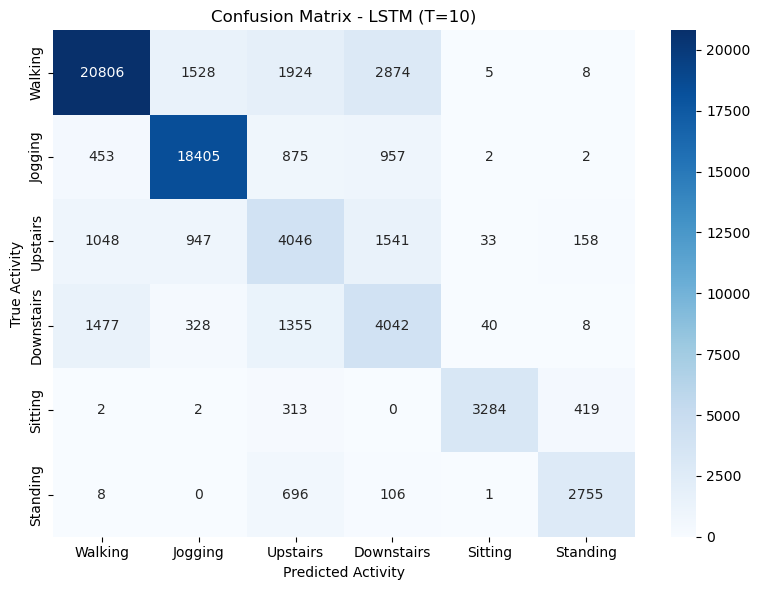


Statring PyTorch Training  LSTM (T=25)
Epoch 01/10 | Train Loss: 0.6138
Epoch 02/10 | Train Loss: 0.3145
Epoch 03/10 | Train Loss: 0.2395
Epoch 04/10 | Train Loss: 0.1988
Epoch 05/10 | Train Loss: 0.1750
Epoch 06/10 | Train Loss: 0.1588
Epoch 07/10 | Train Loss: 0.1465
Epoch 08/10 | Train Loss: 0.1370
Epoch 09/10 | Train Loss: 0.1283
Epoch 10/10 | Train Loss: 0.1223
PyTorch Total Training Time LSTM (T=25): 37.40 seconds

--- Evaluation Results for LSTM (T=25) ---
Accuracy: 79.72%
Macro-F1 Score: 0.7732

Per-Class F1 Scores:
  Walking: 0.8543
  Jogging: 0.8635
  Upstairs: 0.5379
  Downstairs: 0.6517
  Sitting: 0.8890
  Standing: 0.8427


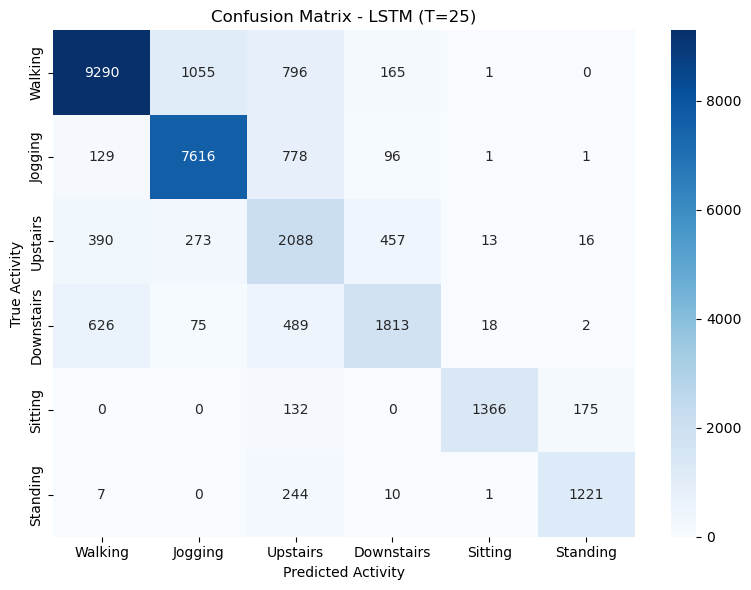


Statring PyTorch Training  LSTM (T=50)
Epoch 01/10 | Train Loss: 0.8384
Epoch 02/10 | Train Loss: 0.5168
Epoch 03/10 | Train Loss: 0.3993
Epoch 04/10 | Train Loss: 0.2772
Epoch 05/10 | Train Loss: 0.2104
Epoch 06/10 | Train Loss: 0.1717
Epoch 07/10 | Train Loss: 0.1515
Epoch 08/10 | Train Loss: 0.1333
Epoch 09/10 | Train Loss: 0.1196
Epoch 10/10 | Train Loss: 0.1117
PyTorch Total Training Time LSTM (T=50): 27.25 seconds

--- Evaluation Results for LSTM (T=50) ---
Accuracy: 85.05%
Macro-F1 Score: 0.8275

Per-Class F1 Scores:
  Walking: 0.8903
  Jogging: 0.9007
  Upstairs: 0.6553
  Downstairs: 0.7702
  Sitting: 0.8833
  Standing: 0.8652


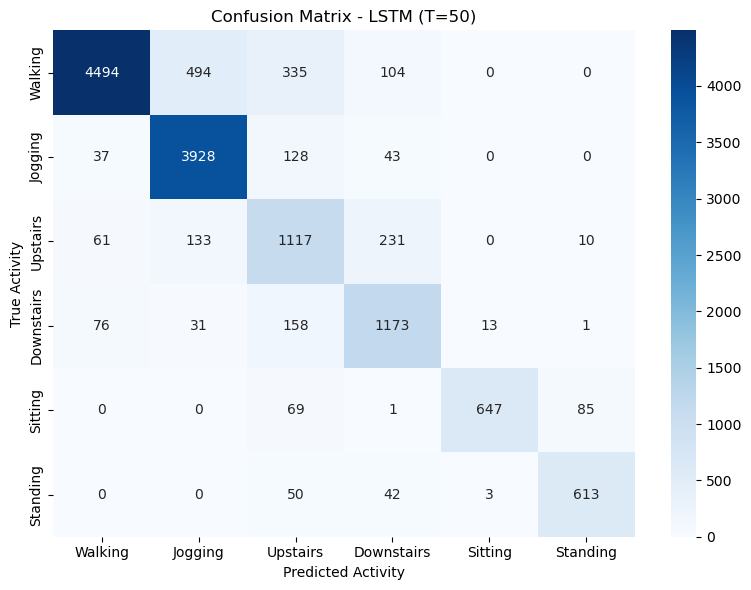


Statring PyTorch Training  LSTM (T=100)
Epoch 01/10 | Train Loss: 1.0212
Epoch 02/10 | Train Loss: 0.7328
Epoch 03/10 | Train Loss: 0.5990
Epoch 04/10 | Train Loss: 0.5198
Epoch 05/10 | Train Loss: 0.4550
Epoch 06/10 | Train Loss: 0.3995
Epoch 07/10 | Train Loss: 0.3658
Epoch 08/10 | Train Loss: 0.3171
Epoch 09/10 | Train Loss: 0.2750
Epoch 10/10 | Train Loss: 0.2521
PyTorch Total Training Time LSTM (T=100): 23.25 seconds

--- Evaluation Results for LSTM (T=100) ---
Accuracy: 78.19%
Macro-F1 Score: 0.7238

Per-Class F1 Scores:
  Walking: 0.8733
  Jogging: 0.8598
  Upstairs: 0.5051
  Downstairs: 0.4883
  Sitting: 0.8453
  Standing: 0.7709


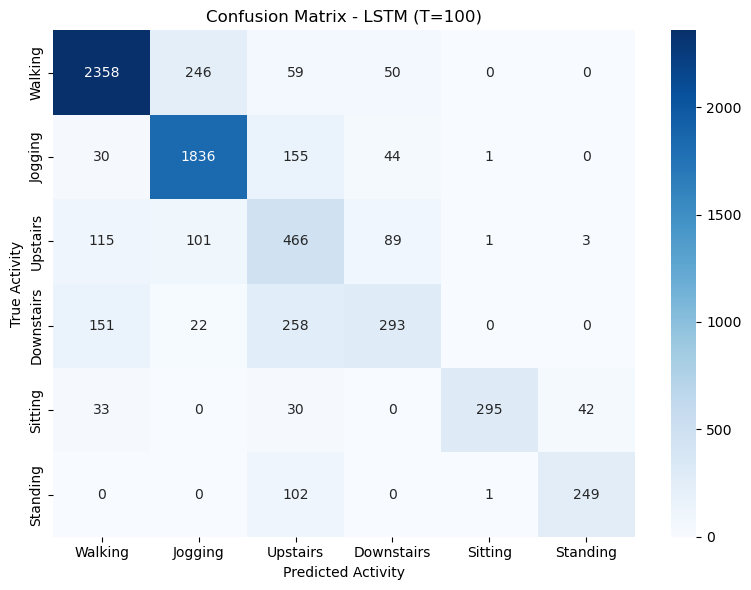


Statring PyTorch Training  LSTM (T=200)
Epoch 01/10 | Train Loss: 1.2437
Epoch 02/10 | Train Loss: 0.9663
Epoch 03/10 | Train Loss: 0.8127
Epoch 04/10 | Train Loss: 0.7176
Epoch 05/10 | Train Loss: 0.6291
Epoch 06/10 | Train Loss: 0.6301
Epoch 07/10 | Train Loss: 0.6163
Epoch 08/10 | Train Loss: 0.5818
Epoch 09/10 | Train Loss: 0.5794
Epoch 10/10 | Train Loss: 0.5537
PyTorch Total Training Time LSTM (T=200): 24.66 seconds

--- Evaluation Results for LSTM (T=200) ---
Accuracy: 73.99%
Macro-F1 Score: 0.5422

Per-Class F1 Scores:
  Walking: 0.8146
  Jogging: 0.9190
  Upstairs: 0.1477
  Downstairs: 0.0000
  Sitting: 0.8626
  Standing: 0.5091


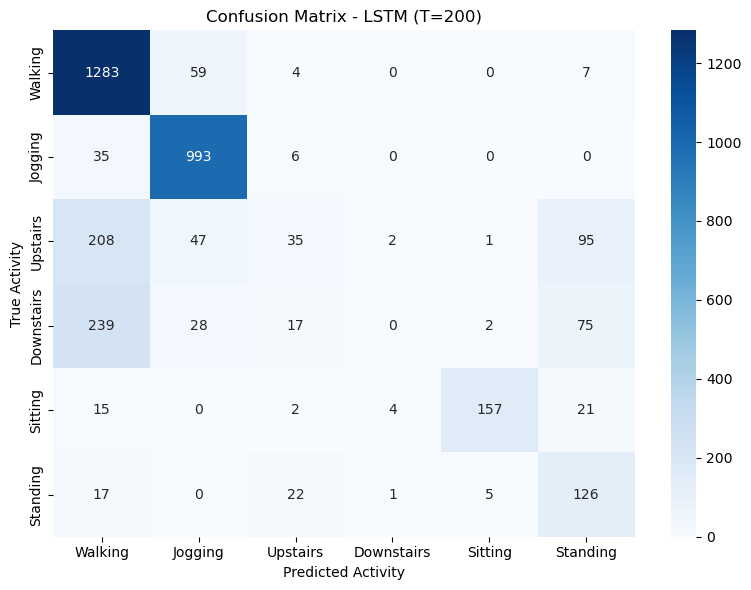


Statring PyTorch Training  LSTM (T=400)
Epoch 01/10 | Train Loss: 1.4574
Epoch 02/10 | Train Loss: 1.1840
Epoch 03/10 | Train Loss: 1.0569
Epoch 04/10 | Train Loss: 0.9657
Epoch 05/10 | Train Loss: 0.9229
Epoch 06/10 | Train Loss: 0.8427
Epoch 07/10 | Train Loss: 0.8047
Epoch 08/10 | Train Loss: 0.7328
Epoch 09/10 | Train Loss: 0.7809
Epoch 10/10 | Train Loss: 0.7787
PyTorch Total Training Time LSTM (T=400): 26.94 seconds

--- Evaluation Results for LSTM (T=400) ---
Accuracy: 57.57%
Macro-F1 Score: 0.4220

Per-Class F1 Scores:
  Walking: 0.6783
  Jogging: 0.7194
  Upstairs: 0.1107
  Downstairs: 0.0000
  Sitting: 0.7273
  Standing: 0.2961


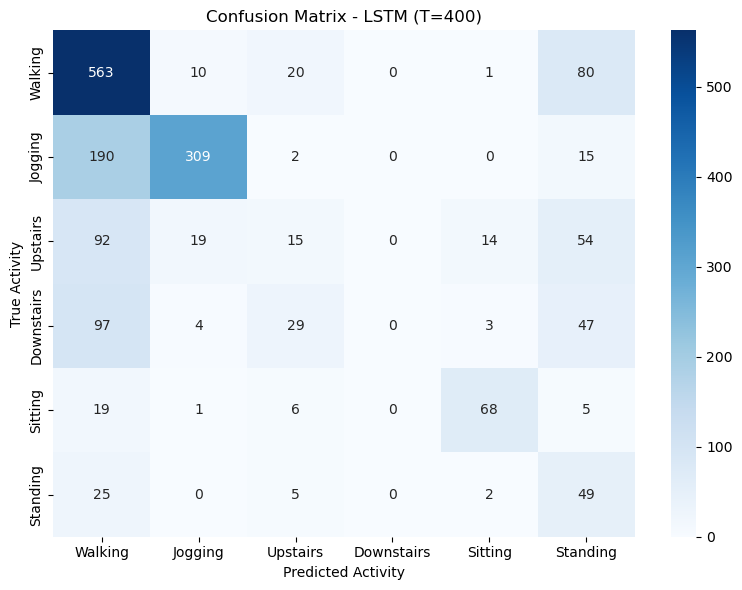


EXPERIMENT 2: Effect of Hidden Layer Size (hidden_dim)

Statring PyTorch Training  LSTM (hidden_dim=8)
Epoch 01/12 | Train Loss: 1.4086
Epoch 02/12 | Train Loss: 0.9325
Epoch 03/12 | Train Loss: 0.8215
Epoch 04/12 | Train Loss: 0.7950
Epoch 05/12 | Train Loss: 0.7630
Epoch 06/12 | Train Loss: 0.7792
Epoch 07/12 | Train Loss: 0.7154
Epoch 08/12 | Train Loss: 0.6914
Epoch 09/12 | Train Loss: 0.6291
Epoch 10/12 | Train Loss: 0.5933
Epoch 11/12 | Train Loss: 0.5796
Epoch 12/12 | Train Loss: 0.5687
PyTorch Total Training Time LSTM (hidden_dim=8): 10.59 seconds

--- Evaluation Results for LSTM (hidden_dim=8) ---
Accuracy: 72.42%
Macro-F1 Score: 0.5676

Per-Class F1 Scores:
  Walking: 0.7870
  Jogging: 0.8800
  Upstairs: 0.2777
  Downstairs: 0.0055
  Sitting: 0.8146
  Standing: 0.6407


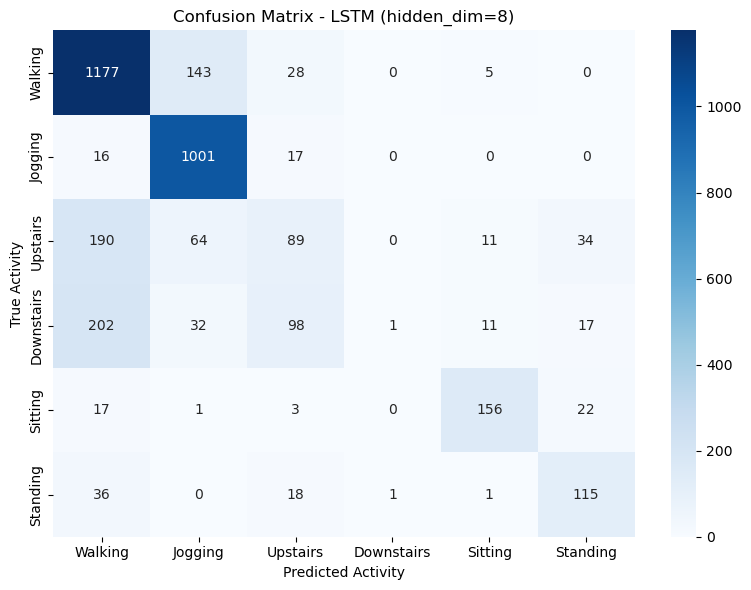


Statring PyTorch Training  LSTM (hidden_dim=16)
Epoch 01/12 | Train Loss: 1.2312
Epoch 02/12 | Train Loss: 0.8586
Epoch 03/12 | Train Loss: 0.7608
Epoch 04/12 | Train Loss: 0.7511
Epoch 05/12 | Train Loss: 0.6994
Epoch 06/12 | Train Loss: 0.6886
Epoch 07/12 | Train Loss: 0.6141
Epoch 08/12 | Train Loss: 0.5675
Epoch 09/12 | Train Loss: 0.5482
Epoch 10/12 | Train Loss: 0.5185
Epoch 11/12 | Train Loss: 0.5074
Epoch 12/12 | Train Loss: 0.5002
PyTorch Total Training Time LSTM (hidden_dim=16): 14.41 seconds

--- Evaluation Results for LSTM (hidden_dim=16) ---
Accuracy: 68.60%
Macro-F1 Score: 0.6004

Per-Class F1 Scores:
  Walking: 0.7239
  Jogging: 0.8910
  Upstairs: 0.2603
  Downstairs: 0.0645
  Sitting: 0.8739
  Standing: 0.7888


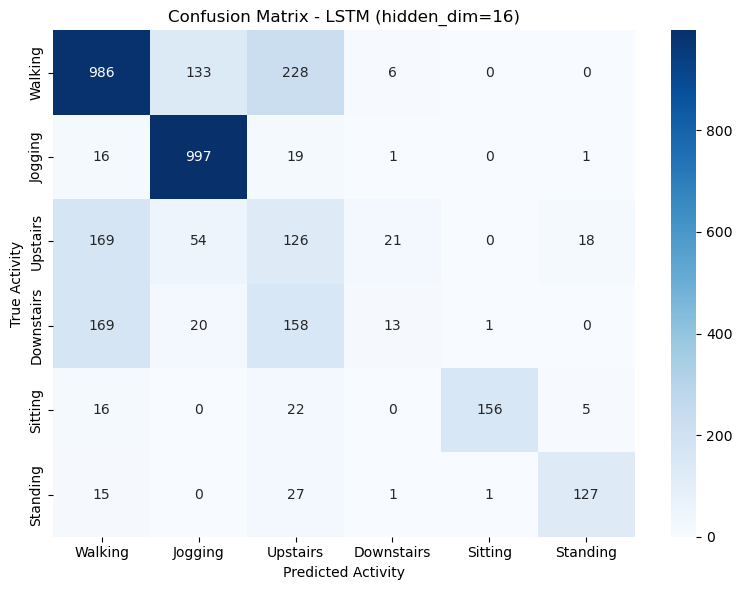


Statring PyTorch Training  LSTM (hidden_dim=32)
Epoch 01/12 | Train Loss: 1.2052
Epoch 02/12 | Train Loss: 0.8956
Epoch 03/12 | Train Loss: 0.7380
Epoch 04/12 | Train Loss: 0.6858
Epoch 05/12 | Train Loss: 0.5592
Epoch 06/12 | Train Loss: 0.4882
Epoch 07/12 | Train Loss: 0.5146
Epoch 08/12 | Train Loss: 0.4204
Epoch 09/12 | Train Loss: 0.3565
Epoch 10/12 | Train Loss: 0.3569
Epoch 11/12 | Train Loss: 0.3103
Epoch 12/12 | Train Loss: 0.2768
PyTorch Total Training Time LSTM (hidden_dim=32): 31.24 seconds

--- Evaluation Results for LSTM (hidden_dim=32) ---
Accuracy: 72.70%
Macro-F1 Score: 0.6554

Per-Class F1 Scores:
  Walking: 0.8586
  Jogging: 0.8257
  Upstairs: 0.4521
  Downstairs: 0.1660
  Sitting: 0.8509
  Standing: 0.7791


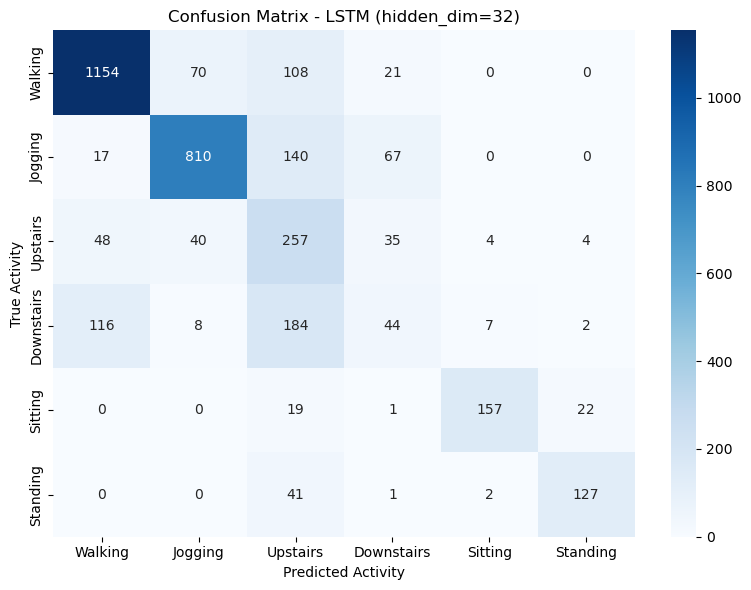


Statring PyTorch Training  LSTM (hidden_dim=64)
Epoch 01/12 | Train Loss: 1.0865
Epoch 02/12 | Train Loss: 0.8019
Epoch 03/12 | Train Loss: 0.7564
Epoch 04/12 | Train Loss: 0.6497
Epoch 05/12 | Train Loss: 0.6147
Epoch 06/12 | Train Loss: 0.4534
Epoch 07/12 | Train Loss: 0.3346
Epoch 08/12 | Train Loss: 0.5111
Epoch 09/12 | Train Loss: 0.4853
Epoch 10/12 | Train Loss: 0.4103
Epoch 11/12 | Train Loss: 0.3067
Epoch 12/12 | Train Loss: 0.2425
PyTorch Total Training Time LSTM (hidden_dim=64): 41.88 seconds

--- Evaluation Results for LSTM (hidden_dim=64) ---
Accuracy: 83.00%
Macro-F1 Score: 0.7762

Per-Class F1 Scores:
  Walking: 0.9121
  Jogging: 0.8926
  Upstairs: 0.5435
  Downstairs: 0.6716
  Sitting: 0.8634
  Standing: 0.7738


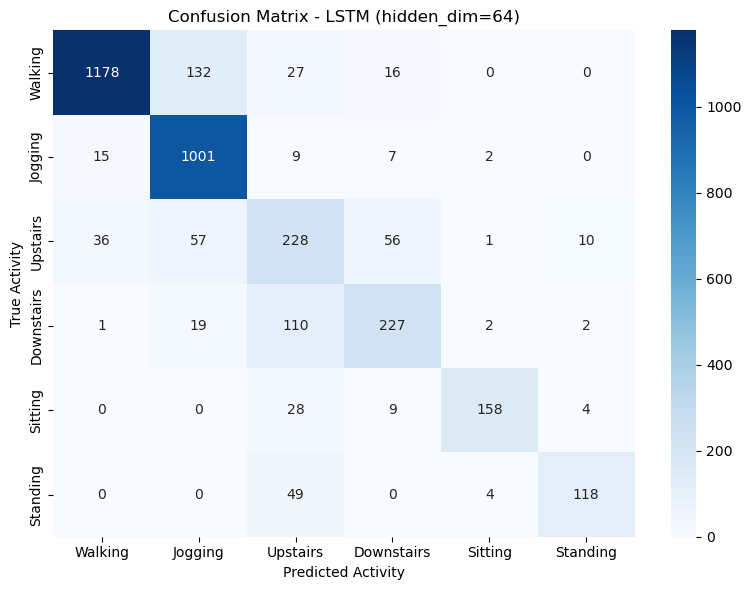


Statring PyTorch Training  LSTM (hidden_dim=128)
Epoch 01/12 | Train Loss: 1.1432
Epoch 02/12 | Train Loss: 0.8427
Epoch 03/12 | Train Loss: 0.6386
Epoch 04/12 | Train Loss: 0.5775
Epoch 05/12 | Train Loss: 1.0418
Epoch 06/12 | Train Loss: 0.5690
Epoch 07/12 | Train Loss: 0.4561
Epoch 08/12 | Train Loss: 0.3965
Epoch 09/12 | Train Loss: 0.3036
Epoch 10/12 | Train Loss: 0.4112
Epoch 11/12 | Train Loss: 0.6783
Epoch 12/12 | Train Loss: 0.3092
PyTorch Total Training Time LSTM (hidden_dim=128): 80.52 seconds

--- Evaluation Results for LSTM (hidden_dim=128) ---
Accuracy: 79.09%
Macro-F1 Score: 0.7460

Per-Class F1 Scores:
  Walking: 0.8215
  Jogging: 0.8929
  Upstairs: 0.4987
  Downstairs: 0.5383
  Sitting: 0.8701
  Standing: 0.8548


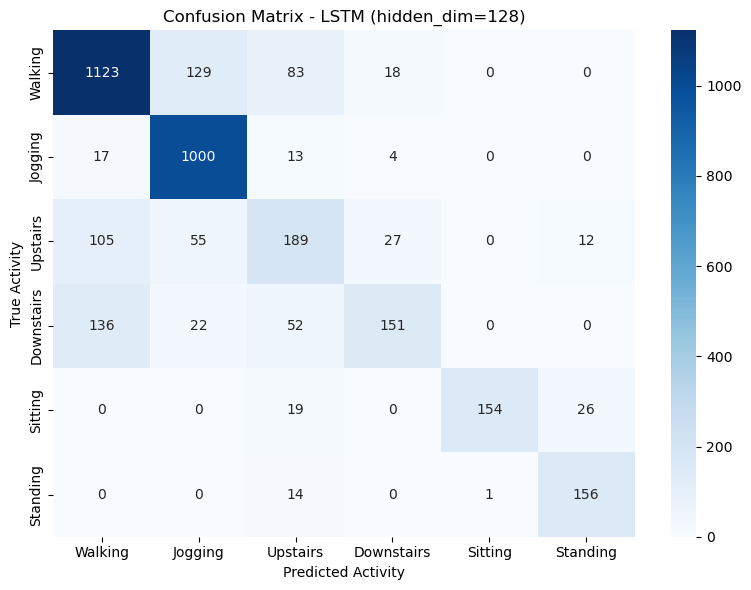


Statring PyTorch Training  LSTM (hidden_dim=256)
Epoch 01/12 | Train Loss: 1.1475
Epoch 02/12 | Train Loss: 0.8895
Epoch 03/12 | Train Loss: 1.0448
Epoch 04/12 | Train Loss: 0.7832
Epoch 05/12 | Train Loss: 0.6848
Epoch 06/12 | Train Loss: 1.3463
Epoch 07/12 | Train Loss: 1.5118
Epoch 08/12 | Train Loss: 1.4843
Epoch 09/12 | Train Loss: 1.4394
Epoch 10/12 | Train Loss: 1.0514
Epoch 11/12 | Train Loss: 0.7567
Epoch 12/12 | Train Loss: 0.6359
PyTorch Total Training Time LSTM (hidden_dim=256): 186.67 seconds

--- Evaluation Results for LSTM (hidden_dim=256) ---
Accuracy: 71.45%
Macro-F1 Score: 0.5302

Per-Class F1 Scores:
  Walking: 0.7895
  Jogging: 0.8814
  Upstairs: 0.1148
  Downstairs: 0.0054
  Sitting: 0.8192
  Standing: 0.5709


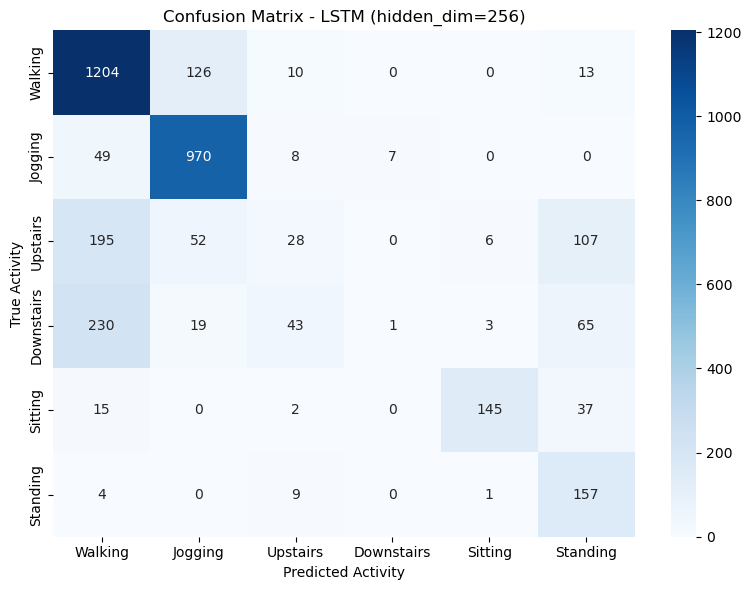

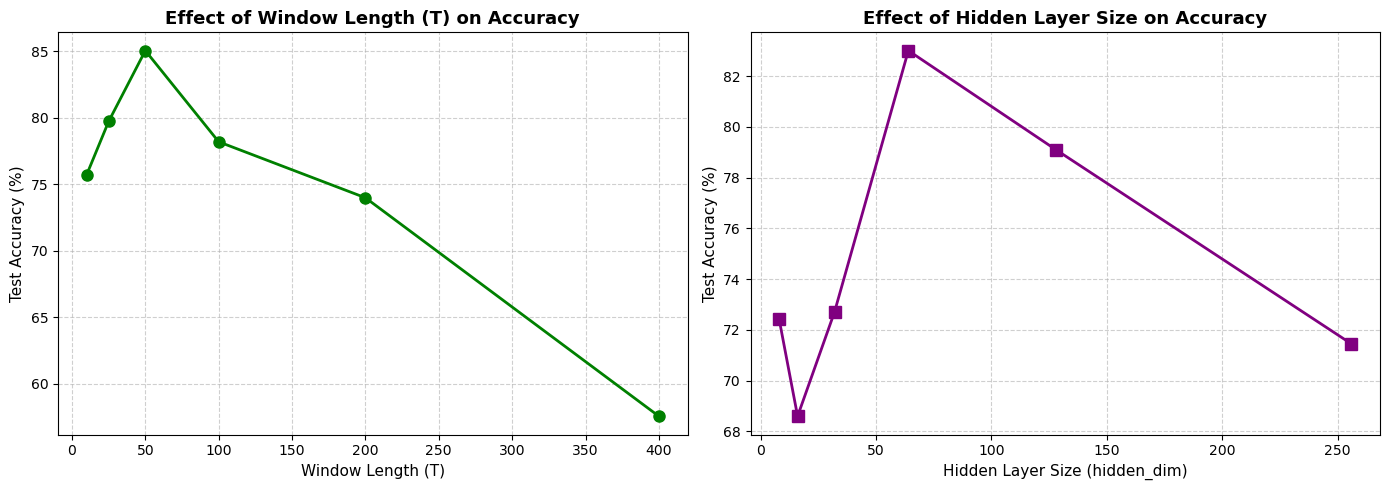

In [8]:
def run_sensitivity_experiments(train_dataset, test_dataset):
    print("\n" + "=" * 70)
    print("EXPERIMENT 1: Effect of Window Length (T)")
    print("=" * 70)

    window_sizes = [10, 25, 50, 100, 200, 400]
    win_accuracies = []

    for w_size in window_sizes:
        step = max(w_size // 2, 5)
        X_tr, y_tr = create_windows(train_dataset, window_size=w_size, step_size=step)
        X_te, y_te = create_windows(test_dataset, window_size=w_size, step_size=step)

        model = PyTorchLSTM(input_dim=3, hidden_dim=32, output_dim=6)
        _, acc, _ = train_pytorch_model(
            model,
            X_tr,
            y_tr,
            X_te,
            y_te,
            epochs=10,
            batch_size=64,
            lr=0.003,
            model_name=f"LSTM (T={w_size})",
        )
        win_accuracies.append(acc * 100)

    print("\n" + "=" * 70)
    print("EXPERIMENT 2: Effect of Hidden Layer Size (hidden_dim)")
    print("=" * 70)

    X_tr, y_tr = create_windows(train_dataset, window_size=200, step_size=100)
    X_te, y_te = create_windows(test_dataset, window_size=200, step_size=100)

    hidden_dims = [8, 16, 32, 64, 128, 256]
    hidden_accuracies = []

    for h_dim in hidden_dims:
        model = PyTorchLSTM(input_dim=3, hidden_dim=h_dim, output_dim=6)
        _, acc, _ = train_pytorch_model(
            model,
            X_tr,
            y_tr,
            X_te,
            y_te,
            epochs=12,
            batch_size=64,
            lr=0.005,
            model_name=f"LSTM (hidden_dim={h_dim})",
        )
        hidden_accuracies.append(acc * 100)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(
        window_sizes,
        win_accuracies,
        marker="o",
        color="green",
        linewidth=2,
        markersize=8,
    )
    ax1.set_title(
        "Effect of Window Length (T) on Accuracy", fontsize=13, fontweight="bold"
    )
    ax1.set_xlabel("Window Length (T)", fontsize=11)
    ax1.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax1.grid(True, linestyle="--", alpha=0.6)

    ax2.plot(
        hidden_dims,
        hidden_accuracies,
        marker="s",
        color="purple",
        linewidth=2,
        markersize=8,
    )
    ax2.set_title(
        "Effect of Hidden Layer Size on Accuracy", fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel("Hidden Layer Size (hidden_dim)", fontsize=11)
    ax2.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


dataset, train_dataset, test_dataset = load_dataset()
run_sensitivity_experiments(train_dataset, test_dataset)